# 10주차: 로지스틱 회귀 II — 교실 실습
## Chain Rule Gradient 유도 · 결정 경계

**교실 실습용** | 손문제(35분) + 🐛 버그 잡기(20분) + 코딩 실습(20분)

---

## 📝 손문제 (35분)

계산기, NumPy 없이 손으로 풀어보세요.

---
### 문제 1. Chain Rule 세 조각 계산 [8분]

$$w_0 = 0,\quad w_1 = 1,\quad w_2 = 1 \qquad
x_0 = 1\ (\text{bias}),\quad x_1 = 2,\quad x_2 = -1 \qquad y = 1$$

**(1)** $z = w_0 x_0 + w_1 x_1 + w_2 x_2$ 를 계산하세요.

**(2)** $\hat{p} = \sigma(z)$ 를 계산하세요. ($e^{-1} \approx 0.368$)

**(3)** 아래 세 조각을 각각 계산하세요.

| 조각 | &nbsp;&nbsp;&nbsp;&nbsp;공식&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 계산 결과 |
|:---:|---|:---:|
| $\dfrac{\partial L}{\partial \hat{p}}$ | $\dfrac{\hat{p} - y}{\hat{p}(1-\hat{p})}$ | |
| $\dfrac{\partial \hat{p}}{\partial z}$ | $\hat{p}(1-\hat{p})$ | |
| $\dfrac{\partial z}{\partial w_1}$ | $x_1$ | |

**(4)** 세 조각을 곱해서 $\dfrac{\partial L}{\partial w_1}$ 을 구하고,
$(\hat{p} - y)x_1$ 과 일치하는지 확인하세요.

**풀이 공간:**

---
### 문제 2. 시그모이드 도함수의 최댓값 [7분]

**(1)** $f(p) = p(1-p)$ 를 미분하고 $f'(p)=0$ 을 풀어 최댓값이 $p=0.5$ 에서 나타남을 보이세요.

**(2)** $p=0.5$ 일 때 $\sigma'(z)$ 최댓값은 얼마인가요?

**(3)** $z \to \pm\infty$ 일 때 $\sigma'(z)$는 어떻게 되나요?
딥러닝에서 어떤 문제와 연결되는지 한 줄로 쓰세요.

**풀이 공간:**

---
### 문제 3. 결정 경계 — 직선 방정식과 이동 [12분]

학습 후 가중치: $w_0 = -0.5,\quad w_1 = 1.2,\quad w_2 = -0.8$

**(1)** $w_0 + w_1 x_1 + w_2 x_2 = 0$ 에서 $x_2$를 $x_1$의 함수로 표현하세요.

**(2)** $x_1 = 0, 1, 2$ 일 때 결정 경계 위의 $x_2$ 값을 구하세요.

**(3)** 두 점의 클래스를 판별하세요. ($z > 0$ → 클래스 1)

| 점 | $x_1$ | $x_2$ | $z$ | 클래스 |
|:---:|:---:|:---:|:---:|:---:|
| A | 1 | 0 | | |
| B | 0 | 2 | | |

**(4)** $w_0$ 만 $-0.5$ 에서 $+1.0$ 으로 바뀌었습니다. 새 결정 경계의 기울기와 절편을 구하고,
경계선이 어느 방향으로 어떻게 이동했는지 서술하세요.

$$x_2 = \quad ? \qquad (\text{기울기: }\quad,\quad \text{절편: }\quad)$$

> **힌트:** 기울기 $= -w_1/w_2$, 절편 $= -w_0/w_2$. $w_0$ 가 바뀌면 무엇이 달라지나요?

**풀이 공간:**

---
### 문제 4. 구조 비교 — 선형회귀 vs 로지스틱 회귀 [8분]

|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;선형회귀&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 로지스틱 회귀 |
|---|---|---|
| 예측값 | $\hat{y} = z = \mathbf{w}^T \mathbf{x}$ | $\hat{p} = \sigma(z)$ |
| Gradient $\partial L / \partial w_i$ | $(\hat{y} - y)\, x_i$ | $(\hat{p} - y)\, x_i$ |

**(1)** 두 gradient에서 "오차"가 의미하는 바를 각각 설명하세요.

**(2)** 로지스틱 회귀 gradient에서 $\hat{p}(1-\hat{p})$ 가 자동 약분되는 이유를 한 문장으로 쓰세요.

**(3) [신규]** XOR 패턴 데이터에서 로지스틱 회귀가 ~50% 정확도에 머무는 이유를,
"결정 경계"와 "선형 함수" 두 단어를 반드시 포함해서 설명하세요.

**풀이 공간:**

---
## 🐛 버그 잡기 팀활동 (20분)

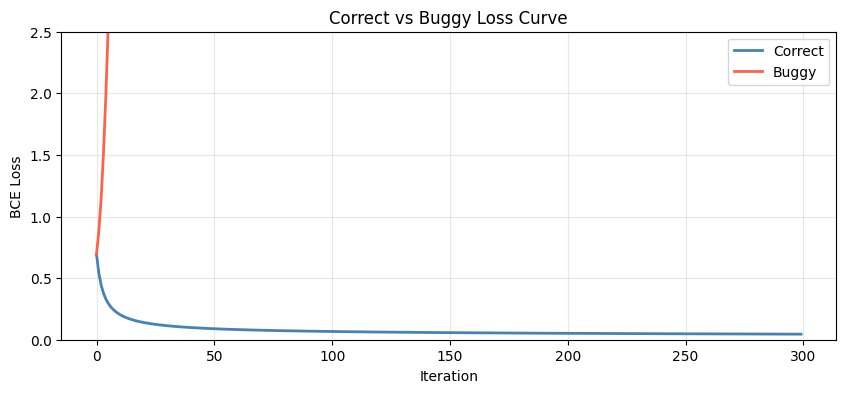

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

np.random.seed(0)
n = 100
X0 = np.random.randn(n//2, 2) + np.array([-1.5, -1.5])
X1 = np.random.randn(n//2, 2) + np.array([ 1.5,  1.5])
X_raw = np.vstack([X0, X1])
y = np.array([0]*(n//2) + [1]*(n//2), dtype=float)
mu = X_raw.mean(axis=0); std = X_raw.std(axis=0)
X_std = (X_raw - mu) / std
X_b   = np.hstack([np.ones((n, 1)), X_std])

def correct_logistic(X, y, lr=0.5, n_iter=300):
    ns, d = X.shape; w = np.zeros(d); losses = []
    for _ in range(n_iter):
        p_hat = sigmoid(X @ w); eps = 1e-12
        losses.append(-np.mean(y*np.log(p_hat+eps)+(1-y)*np.log(1-p_hat+eps)))
        w = w - lr * (X.T @ (p_hat - y) / ns)   # correct
    return losses

def buggy_logistic(X, y, lr=0.5, n_iter=300):
    ns, d = X.shape; w = np.zeros(d); losses = []
    for _ in range(n_iter):
        p_hat = sigmoid(X @ w); eps = 1e-12
        losses.append(-np.mean(y*np.log(p_hat+eps)+(1-y)*np.log(1-p_hat+eps)))
        grad = X.T @ (y - p_hat) / ns   # <- 버그
        w    = w - lr * grad
    return losses

cl = correct_logistic(X_b, y)
bl = buggy_logistic(X_b, y)

plt.figure(figsize=(10, 4))
plt.plot(cl, color='steelblue', label='Correct', linewidth=2)
plt.plot(bl, color='tomato',    label='Buggy',   linewidth=2)
plt.xlabel('Iteration'); plt.ylabel('BCE Loss')
plt.title('Correct vs Buggy Loss Curve')
plt.legend(); plt.ylim(0, 2.5); plt.grid(True, alpha=0.3)
plt.show()

**팀 토론 질문:**
1. 버그 코드에서 무엇이 달라졌나요?
2. `w = w - lr * grad` 에서 `grad` 부호가 반전되면 어떻게 되나요?
3. 이 버그 유형은? (shape / axis / 논리 오류 중 선택)
4. $\dfrac{\partial L}{\partial \hat{p}}$ 의 분자가 $\hat{p}-y$ 인지 $y-\hat{p}$ 인지 유도 과정에서 확인하세요.

In [ ]:
def fixed_logistic(X, y, lr=0.5, n_iter=300):
    ns, d = X.shape; w = np.zeros(d); losses = []
    for _ in range(n_iter):
        p_hat = sigmoid(X @ w); eps = 1e-12
        losses.append(-np.mean(y*np.log(p_hat+eps)+(1-y)*np.log(1-p_hat+eps)))
        grad = ______   # 수정된 gradient
        w    = w - lr * grad
    return losses

---
## 💻 코딩 실습 (20분)

### 실습 1. 손계산 결과 NumPy 검증

In [2]:
w = np.array([0.0, 1.0, 1.0])
x = np.array([1.0, 2.0, -1.0])
y_val = 1.0

z     = np.dot(w, x)
p_hat = sigmoid(z)
print(f'z     = {z}')
print(f'p_hat = {p_hat:.4f}')

dL_dphat = (p_hat - y_val) / (p_hat * (1 - p_hat))
dphat_dz  = p_hat * (1 - p_hat)
dz_dw1    = x[1]
chain     = dL_dphat * dphat_dz * dz_dw1
shortcut  = (p_hat - y_val) * x[1]

print(f'\nChain rule: {chain:.4f}')
print(f'Shortcut:   {shortcut:.4f}')
print(f'Match:      {np.isclose(chain, shortcut)}')

z     = 1.0
p_hat = 0.7311

Chain rule: -0.5379
Shortcut:   -0.5379
Match:      True


### 실습 2. $w_0$ 변화에 따른 결정 경계 이동 시각화 (손문제 3-4 확인)

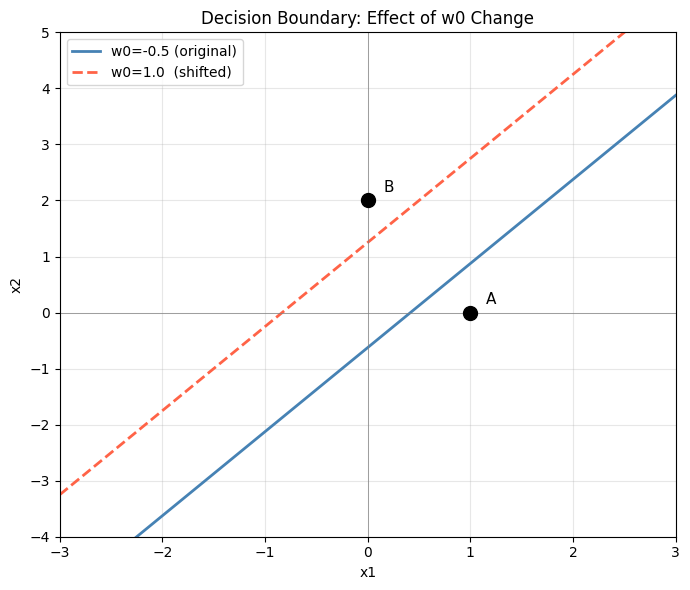

Original: slope=1.500, intercept=-0.625
Shifted: slope=1.500, intercept=1.250


In [3]:
# 손문제 3의 두 가중치 세트 비교
w_original = np.array([-0.5,  1.2, -0.8])   # 원래 가중치
w_shifted  = np.array([ 1.0,  1.2, -0.8])   # w0만 변경

x1r = np.linspace(-3, 3, 200)

fig, ax = plt.subplots(figsize=(7, 6))

for w, label, color, ls in [
    (w_original, f'w0={w_original[0]} (original)', 'steelblue', '-'),
    (w_shifted,  f'w0={w_shifted[0]}  (shifted)',  'tomato',    '--'),
]:
    x2db = -(w[1]*x1r + w[0]) / w[2]
    ax.plot(x1r, x2db, color=color, linestyle=ls, linewidth=2, label=label)

# 손문제 3의 두 점
points = [(1, 0, 'A'), (0, 2, 'B')]
for px, py, lbl in points:
    ax.scatter(px, py, c='black', s=100, zorder=5)
    ax.annotate(lbl, xy=(px, py), xytext=(px+0.15, py+0.15), fontsize=11)

ax.set_xlim(-3, 3); ax.set_ylim(-4, 5)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Decision Boundary: Effect of w0 Change')
ax.legend(); ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout(); plt.show()

# 두 경계의 기울기·절편 출력
for w, label in [(w_original, 'Original'), (w_shifted, 'Shifted')]:
    slope     = -w[1] / w[2]
    intercept = -w[0] / w[2]
    print(f'{label}: slope={slope:.3f}, intercept={intercept:.3f}')

### 실습 3. 선형 분리 가능 vs 불가능 — 정확도 비교

In [4]:
def logistic_gd(X, y, lr=0.3, n_iter=1000):
    w = np.zeros(X.shape[1])
    for _ in range(n_iter):
        p_hat = sigmoid(X @ w)
        w = w - lr * (X.T @ (p_hat - y) / len(y))
    return w

# Case 1: 선형 분리 가능 데이터 (수업 예시)
np.random.seed(0)
n = 100
X0 = np.random.randn(n//2, 2) + np.array([-1.5, -1.5])
X1 = np.random.randn(n//2, 2) + np.array([ 1.5,  1.5])
X_lin = np.vstack([X0, X1])
y_lin = np.array([0]*(n//2)+[1]*(n//2), dtype=float)
mu = X_lin.mean(0); std = X_lin.std(0)
Xs_lin = (X_lin-mu)/std
Xb_lin = np.hstack([np.ones((n,1)), Xs_lin])
w_lin  = logistic_gd(Xb_lin, y_lin)
acc_lin = np.mean((sigmoid(Xb_lin @ w_lin) >= 0.5) == y_lin)

# Case 2: XOR 데이터 (선형 분리 불가)
np.random.seed(1)
X_xor = np.random.randn(200, 2) * 0.7
y_xor = ((X_xor[:,0] * X_xor[:,1]) > 0).astype(float)
mu2 = X_xor.mean(0); std2 = X_xor.std(0)
Xs_xor = (X_xor-mu2)/std2
Xb_xor = np.hstack([np.ones((200,1)), Xs_xor])
w_xor  = logistic_gd(Xb_xor, y_xor)
acc_xor = np.mean((sigmoid(Xb_xor @ w_xor) >= 0.5) == y_xor)

print(f'선형 분리 가능 데이터 정확도: {acc_lin:.1%}')
print(f'XOR 데이터 정확도:            {acc_xor:.1%}')
print()
print('XOR 정확도가 ~50%인 이유를 결정 경계 관점에서 설명해보세요.')

선형 분리 가능 데이터 정확도: 99.0%
XOR 데이터 정확도:            55.5%

XOR 정확도가 ~50%인 이유를 결정 경계 관점에서 설명해보세요.
